In [133]:
import pymc as pm
import pandas as pd
import numpy as np
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
from graphviz import Digraph
from IPython.display import Image, display

## Data

In [2]:
df=pd.read_excel('data/raw/P_Data_Extract_From_World_Development_Indicators.xlsx')
df.shape

(434, 14)

In [3]:
df.head()

,Country Name,Country Code,Series Name,Series Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Afghanistan,AFG,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,100402257640.593002,102671664129.973007,105389386367.804993,106642706595.940994,110814146350.335007,108208794210.783005,85767546197.754395,80415503801.350998,82238478027.944199,..
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,33831764,34700612,35688935,36743039,37856121,39068979,40000412,40578842,41454761,42647492
2,Albania,ALB,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,37899485663.613503,39380952118.1987,40673898060.448097,42167207396.169197,43036938897.712402,41610799594.014603,45343111967.176201,47531686192.787598,49402826580.4701,51360027803.094002
3,Albania,ALB,"Population, total",SP.POP.TOTL,2880703,2876101,2873457,2866376,2854191,2837849,2811666,2777689,2745972,2714617
4,Algeria,DZA,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,609878298356.213989,633663551993.18103,643168505266.462036,652172864345.870972,658042420119.890991,625140299119.911011,648895630480.26001,672255873183.708984,699818363984.641968,722912369991.909058


In [4]:
df.tail()

,Country Name,Country Code,Series Name,Series Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
429,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,31159379,32109010,33090921,34085182,35111408,36134863,37140230,38222876,39390799,40583164
430,Zambia,ZMB,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,58658318773.713097,60860997487.808403,63006872740.594101,65548881175.797096,66493641150.184196,64641756629.1278,68672119764.936302,72250777479.193298,76129157926.519501,79207172680.606796
431,Zambia,ZMB,"Population, total",SP.POP.TOTL,16399089,16914423,17441320,17973569,18513839,19059395,19603607,20152938,20723965,21314956
432,Zimbabwe,ZWE,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,48476202606.453201,48842582863.537697,51154991589.474297,53717816451.014801,50316162716.873901,46382982069.252701,50310711158.786903,53399374351.456001,56249176341.422997,57390744456.049103
433,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,14399013,14600294,14812482,15034452,15271368,15526888,15797210,16069056,16340822,16634373


In [5]:
df.columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]',
       '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]',
       '2023 [YR2023]', '2024 [YR2024]'],
      dtype='object')

In [6]:
df_melt=df.melt(value_vars=['2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]',
       '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]',
       '2023 [YR2023]', '2024 [YR2024]'], id_vars=['Country Name','Series Name'])
df_melt.head()

,Country Name,Series Name,variable,value
0,Afghanistan,"GDP, PPP (constant 2021 international $)",2015 [YR2015],100402257640.593002
1,Afghanistan,"Population, total",2015 [YR2015],33831764
2,Albania,"GDP, PPP (constant 2021 international $)",2015 [YR2015],37899485663.613503
3,Albania,"Population, total",2015 [YR2015],2880703
4,Algeria,"GDP, PPP (constant 2021 international $)",2015 [YR2015],609878298356.213989


In [7]:
df_melt['varname']=df_melt['Series Name'].apply(lambda x: x.split(', ')[0])
df_melt['year']=df_melt['variable'].apply(lambda x: x.split(' [')[0])

In [8]:
df_melt.head()

,Country Name,Series Name,variable,value,varname,year
0,Afghanistan,"GDP, PPP (constant 2021 international $)",2015 [YR2015],100402257640.593002,GDP,2015
1,Afghanistan,"Population, total",2015 [YR2015],33831764,Population,2015
2,Albania,"GDP, PPP (constant 2021 international $)",2015 [YR2015],37899485663.613503,GDP,2015
3,Albania,"Population, total",2015 [YR2015],2880703,Population,2015
4,Algeria,"GDP, PPP (constant 2021 international $)",2015 [YR2015],609878298356.213989,GDP,2015


In [9]:
df_model=df_melt[['Country Name', 'varname','value', 'year']].pivot(index=["Country Name", "year"],columns="varname").reset_index()
colnames=list(df_model.columns.get_level_values(1))
colnames[0]='country'
colnames[1]='year'
df_model.columns = colnames

df_model

,country,year,GDP,Population
0,Afghanistan,2015,100402257640.593002,33831764
1,Afghanistan,2016,102671664129.973007,34700612
2,Afghanistan,2017,105389386367.804993,35688935
3,Afghanistan,2018,106642706595.940994,36743039
4,Afghanistan,2019,110814146350.335007,37856121
...,...,...,...,...
2165,Zimbabwe,2020,46382982069.252701,15526888
2166,Zimbabwe,2021,50310711158.786903,15797210
2167,Zimbabwe,2022,53399374351.456001,16069056
2168,Zimbabwe,2023,56249176341.422997,16340822


In [10]:
df_model.isna().sum()

country       0
year          0
GDP           0
Population    0
dtype: int64

In [11]:
# df_model.GDP.sum()
df_model[df_model.GDP=='..']

,country,year,GDP,Population
9,Afghanistan,2024,..,42647492
30,American Samoa,2015,..,52878
31,American Samoa,2016,..,52245
32,American Samoa,2017,..,51586
33,American Samoa,2018,..,50908
...,...,...,...,...
2145,"Yemen, Rep.",2020,..,36134863
2146,"Yemen, Rep.",2021,..,37140230
2147,"Yemen, Rep.",2022,..,38222876
2148,"Yemen, Rep.",2023,..,39390799


In [12]:
df_model['GDP']=df_model['GDP'].replace('..', np.nan)

/tmp/ipykernel_724/2431319527.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model['GDP']=df_model['GDP'].replace('..', np.nan)


## Drop nan gdp

In [13]:
df_model.shape

(2170, 4)

In [14]:
df_model=df_model[~np.isnan(df_model['GDP'])]
df_model.shape

(1973, 4)

In [15]:
df_model[df_model.Population=='...']

,country,year,GDP,Population


In [16]:
df_model.Population.value_counts()

Population
33831764    1
5379475     1
5311916     1
5276968     1
5234519     1
           ..
2759988     1
2697845     1
2636470     1
2576010     1
16634373    1
Name: count, Length: 1973, dtype: int64

In [17]:
df_model.Population.max()

1450935791

In [18]:
df_model['Population']=pd.to_numeric(df_model["Population"], errors="raise")

/tmp/ipykernel_724/1192782045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Population']=pd.to_numeric(df_model["Population"], errors="raise")


## Log and standardize the population and gdp

In [19]:
df_model["gdp_log"] = np.log(df_model["GDP"])
df_model["population_log"] = np.log(df_model["Population"])

/tmp/ipykernel_724/2415290901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["gdp_log"] = np.log(df_model["GDP"])
/tmp/ipykernel_724/2415290901.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["population_log"] = np.log(df_model["Population"])


In [20]:
# df_model["gdp_log_std"] = (df_model["gdp_log"] - df_model["gdp_log"].mean()) / df_model["gdp_log"].std()
# df_model["population_log_std"] = (df_model["population_log"] - df_model["population_log"].mean()) / df_model["population_log"].std()

In [21]:
m_g, s_g = df_model["gdp_log"].mean(), df_model["gdp_log"].std()
m_p, s_p = df_model["population_log"].mean(), df_model["population_log"].std()

df_model["gdp_log_std"] = (df_model["gdp_log"] - m_g) / s_g
df_model["population_log_std"] = (df_model["population_log"] - m_p) / s_p

/tmp/ipykernel_724/1759121782.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["gdp_log_std"] = (df_model["gdp_log"] - m_g) / s_g
/tmp/ipykernel_724/1759121782.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["population_log_std"] = (df_model["population_log"] - m_p) / s_p


In [22]:
obs_idx_g = np.where(~np.isnan(df_model["gdp_log_std"]))[0]   # indices of rows with GDP observed
obs_idx_g

array([   0,    1,    2, ..., 1970, 1971, 1972])

In [23]:
# Clean year, ensure ints
df_model["year"] = df_model["year"].astype(int)

# Build indices for modeling
df_model = df_model.sort_values(["country","year"]).reset_index(drop=True)
df_model["country_idx"] = df_model["country"].astype("category").cat.codes
df_model["year_idx"]    = df_model["year"].astype("category").cat.codes

# Keep dictionaries to decode later
idx_to_country = dict(enumerate(df_model["country"].astype("category").cat.categories))
idx_to_year    = dict(enumerate(df_model["year"].astype("category").cat.categories))

/tmp/ipykernel_724/3975577331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["year"] = df_model["year"].astype(int)


(array([ 19.,  42., 124., 216., 275., 516., 365., 277., 110.,  29.]),
 array([-3.09691107, -2.53344499, -1.9699789 , -1.40651282, -0.84304673,
        -0.27958065,  0.28388543,  0.84735152,  1.4108176 ,  1.97428369,
         2.53774977]),
 <BarContainer object of 10 artists>)

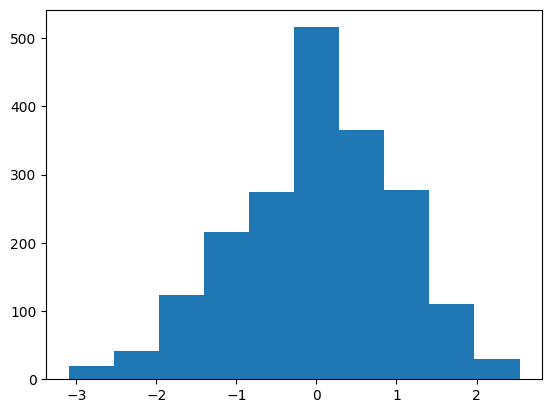

In [24]:
plt.hist(df_model["gdp_log_std"])

(array([ 28., 141., 112., 165., 291., 513., 373., 260.,  70.,  20.]),
 array([-2.70968661, -2.19484729, -1.68000797, -1.16516865, -0.65032932,
        -0.13549   ,  0.37934932,  0.89418864,  1.40902796,  1.92386728,
         2.4387066 ]),
 <BarContainer object of 10 artists>)

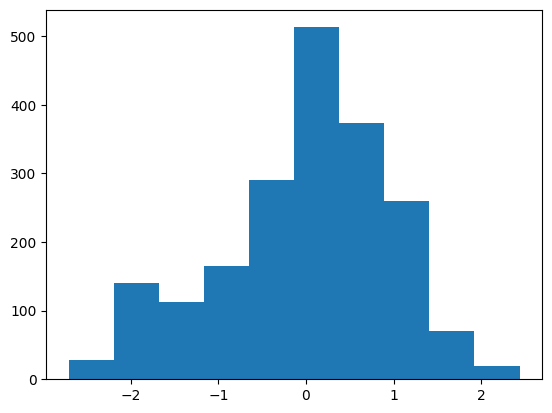

In [25]:
plt.hist(df_model["population_log_std"])

## DAG 1

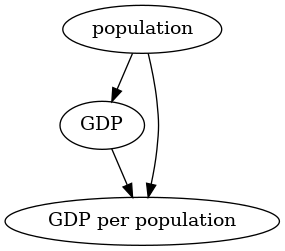

In [26]:
dot = Digraph()

dot.node('GDP')
dot.node('population')
dot.node('GDP per population')

dot.edges([('population', 'GDP'), 
           ('population', 'GDP per population'), 
           ('GDP', 'GDP per population')])

png = dot.pipe(format='png')
display(Image(png))

## Model 1

In [27]:
n_obs = len(df_model)
N_COUNTRIES=df_model.country_idx.nunique()
N_COUNTRIES

199

In [40]:
with pm.Model() as model1:
    # Population country intercepts (CENTERED; no row residual)
    mu_pop_c    = pm.Normal("mu_pop_c", 0, 0.3)
    sigma_pop_c = pm.HalfNormal("sigma_pop_c", 0.2)
    a_pop_c     = pm.Normal("a_pop_c", mu_pop_c, sigma_pop_c, shape=N_COUNTRIES)

    # Observation noise moderate (lets hierarchy breathe)
    sigma_me_p  = pm.HalfNormal("sigma_me_p", 0.1)
    pm.Normal("pop_obs", mu=a_pop_c[df_model.country_idx], sigma=sigma_me_p, observed=df_model["population_log_std"].values)

    # GDP country intercepts
    mu_gdp_c    = pm.Normal("mu_gdp_c", 0, 0.1)
    sigma_gdp_c = pm.HalfNormal("sigma_gdp_c", 0.1)
    z_gdp_c    = pm.Normal("z_gdp_c", 0, 0.05, shape=N_COUNTRIES)
    a_gdp_c    = pm.Deterministic("a_gdp_c", mu_gdp_c + sigma_gdp_c * z_gdp_c)

    #alpha_gdp = pm.Normal("alpha_gdp", 0, 0.3)
    beta_pop  = pm.Normal("beta_pop", 1.0, 0.2)
    sigma_gdp = pm.HalfNormal("sigma_gdp", 0.3)

    #mu_gdp = alpha_gdp + a_gdp_c[df_model.country_idx] + beta_pop * a_pop_c[df_model.country_idx]
    mu_gdp = a_gdp_c[df_model.country_idx] + beta_pop * a_pop_c[df_model.country_idx]
    pm.Normal("gdp_obs", mu=mu_gdp, sigma=sigma_gdp, observed=df_model["gdp_log_std"].values)

    # Back-transform (mean log-levels)
    log_pop_true = pm.Deterministic("log_pop_true", m_p + s_p * a_pop_c[df_model.country_idx])
    log_gdp_true = pm.Deterministic("log_gdp_true", m_g + s_g * mu_gdp)
    log_gdp_percap = pm.Deterministic("log_gdp_percap", log_gdp_true - log_pop_true)
    gdp_percap = pm.Deterministic("gdp_percap", pm.math.exp(log_gdp_percap))

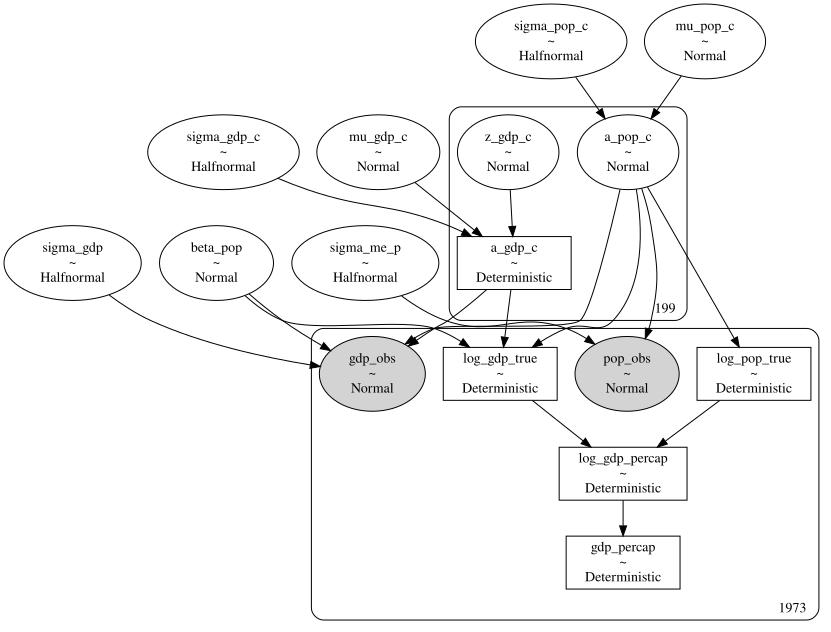

In [29]:
pm.model_to_graphviz(model1)

### prior predictive

In [30]:
with model1:
    prior_pred = pm.sample_prior_predictive(1000) 

/usr/local/lib/python3.11/dist-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sampling: [a_pop_c, beta_pop, gdp_obs, mu_gdp_c, mu_pop_c, pop_obs, sigma_gdp, sigma_gdp_c, sigma_me_p, sigma_pop_c, z_gdp_c]


In [31]:
az.summary(prior_pred)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_gdp_percap[0],9.596,0.290,9.033,10.125,0.009,0.007,966.0,844.0,NaN
log_gdp_percap[1],9.596,0.290,9.033,10.125,0.009,0.007,966.0,844.0,NaN
log_gdp_percap[2],9.596,0.290,9.033,10.125,0.009,0.007,966.0,844.0,NaN
log_gdp_percap[3],9.596,0.290,9.033,10.125,0.009,0.007,966.0,844.0,NaN
log_gdp_percap[4],9.596,0.290,9.033,10.125,0.009,0.007,966.0,844.0,NaN
...,...,...,...,...,...,...,...,...,...
a_gdp_c[198],-0.001,0.101,-0.195,0.179,0.003,0.002,1053.0,1017.0,NaN
sigma_gdp,0.233,0.179,0.000,0.556,0.005,0.005,1111.0,1026.0,NaN
mu_pop_c,0.002,0.290,-0.550,0.520,0.009,0.006,1031.0,1012.0,NaN
sigma_gdp_c,0.080,0.062,0.000,0.194,0.002,0.001,927.0,900.0,NaN


In [32]:
# az.summary(prior_pred, var_names=["log_gdp_percap","log_pop_std"])  # deterministics in prior group

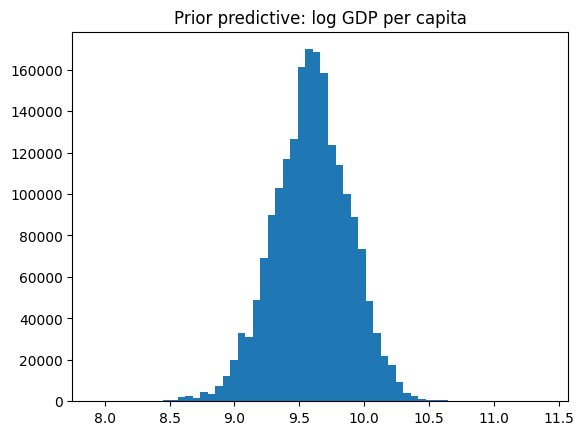

In [33]:
lgpc = prior_pred.prior["log_gdp_percap"].values.ravel()
plt.hist(lgpc[np.isfinite(lgpc)], bins=60)
plt.title("Prior predictive: log GDP per capita")
plt.show()

In [34]:
prior_pred

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

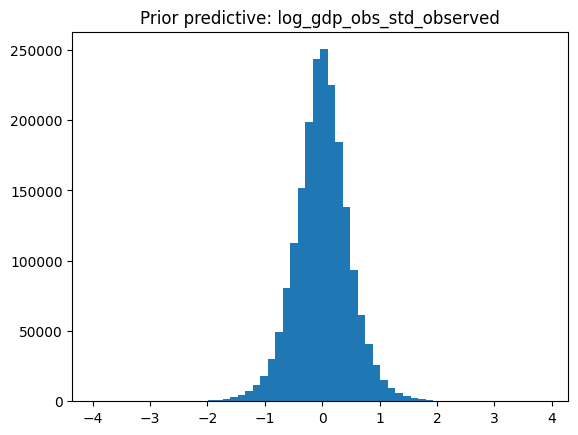

In [35]:
# Fake observed standardized logs (should look roughly N(0, ~1) if your priors are very wide)
plt.hist(prior_pred.prior_predictive["gdp_obs"].values.ravel(), bins=60)
plt.title("Prior predictive: log_gdp_obs_std_observed")
plt.show()

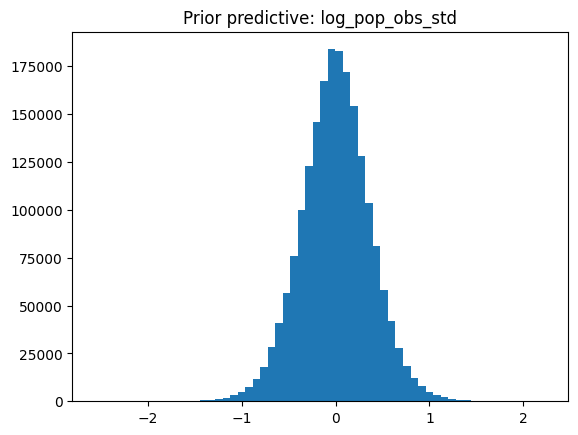

In [36]:
plt.hist(prior_pred.prior_predictive["pop_obs"].values.ravel(), bins=60)
plt.title("Prior predictive: log_pop_obs_std")
plt.show()

In [37]:
with model1:
    trace_model1 = pm.sample(draws=4000, tune=4000,
                             target_accept=0.995, random_seed=42,
                            init="jitter+adapt_diag")
    post_pred_model1 = pm.sample_posterior_predictive(trace_model1, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop_c, sigma_pop_c, a_pop_c, sigma_me_p, mu_gdp_c, sigma_gdp_c, z_gdp_c, beta_pop, sigma_gdp]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 147 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [gdp_obs, pop_obs]


Output()

array([[<Axes: title={'center': 'mu_pop_c'}>,
        <Axes: title={'center': 'mu_pop_c'}>],
       [<Axes: title={'center': 'sigma_pop_c'}>,
        <Axes: title={'center': 'sigma_pop_c'}>],
       [<Axes: title={'center': 'sigma_me_p'}>,
        <Axes: title={'center': 'sigma_me_p'}>],
       [<Axes: title={'center': 'mu_gdp_c'}>,
        <Axes: title={'center': 'mu_gdp_c'}>],
       [<Axes: title={'center': 'sigma_gdp_c'}>,
        <Axes: title={'center': 'sigma_gdp_c'}>],
       [<Axes: title={'center': 'beta_pop'}>,
        <Axes: title={'center': 'beta_pop'}>],
       [<Axes: title={'center': 'sigma_gdp'}>,
        <Axes: title={'center': 'sigma_gdp'}>]], dtype=object)

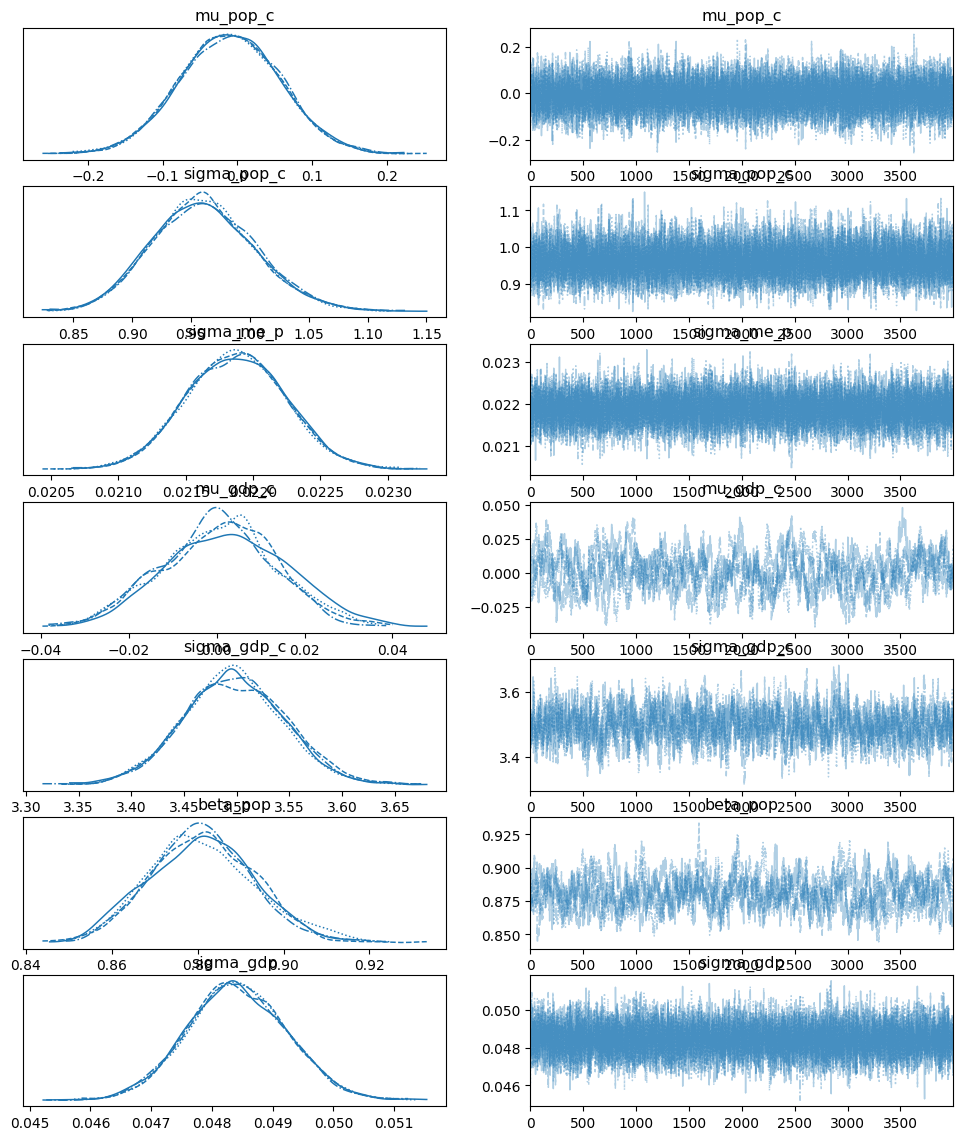

In [39]:
az.plot_trace(trace_model1, var_names=["mu_pop_c","sigma_pop_c", "sigma_me_p", "mu_gdp_c", "sigma_gdp_c", "beta_pop", "sigma_gdp"])

In [40]:
df_summary1=az.summary(trace_model1)
df_summary1.sort_values('r_hat', ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_pop,0.881,0.012,0.858,0.903,0.001,0.0,345.0,652.0,1.01
mu_gdp_c,0.001,0.013,-0.025,0.025,0.001,0.0,254.0,550.0,1.01
log_gdp_percap[1109],7.958,0.040,7.887,8.035,0.000,0.0,26607.0,12824.0,1.00
log_gdp_percap[1110],7.958,0.040,7.887,8.035,0.000,0.0,26607.0,12824.0,1.00
log_gdp_percap[1111],10.876,0.040,10.803,10.952,0.000,0.0,28189.0,13045.0,1.00
...,...,...,...,...,...,...,...,...,...
log_gdp_true[257],24.267,0.037,24.198,24.337,0.000,0.0,32165.0,10805.0,1.00
log_gdp_true[258],24.267,0.037,24.198,24.337,0.000,0.0,32165.0,10805.0,1.00
log_gdp_true[259],24.267,0.037,24.198,24.337,0.000,0.0,32165.0,10805.0,1.00
log_gdp_true[260],24.267,0.037,24.198,24.337,0.000,0.0,32165.0,10805.0,1.00


In [41]:
df_summary1[df_summary1.r_hat>1.01].shape

(0, 9)

In [42]:
df_summary1.shape

(8496, 9)

In [43]:
df_summary1.sort_values('r_hat', ascending=False).head(20)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_pop,0.881,0.012,0.858,0.903,0.001,0.0,345.0,652.0,1.01
mu_gdp_c,0.001,0.013,-0.025,0.025,0.001,0.0,254.0,550.0,1.01
log_gdp_percap[1109],7.958,0.040,7.887,8.035,0.000,0.0,26607.0,12824.0,1.00
log_gdp_percap[1110],7.958,0.040,7.887,8.035,0.000,0.0,26607.0,12824.0,1.00
log_gdp_percap[1111],10.876,0.040,10.803,10.952,0.000,0.0,28189.0,13045.0,1.00
log_gdp_percap[1112],10.876,0.040,10.803,10.952,0.000,0.0,28189.0,13045.0,1.00
log_gdp_percap[1113],10.876,0.040,10.803,10.952,0.000,0.0,28189.0,13045.0,1.00
log_gdp_percap[1114],10.876,0.040,10.803,10.952,0.000,0.0,28189.0,13045.0,1.00
log_gdp_percap[1115],10.876,0.040,10.803,10.952,0.000,0.0,28189.0,13045.0,1.00
log_gdp_percap[1116],10.876,0.040,10.803,10.952,0.000,0.0,28189.0,13045.0,1.00


## Save

In [44]:
az.to_netcdf(trace_model1, 'models/model1.netcdf')

'models/model1.netcdf'

## Load 

In [28]:
trace_model1=az.from_netcdf('models/model1.netcdf')

### interpret results

In [29]:
#compare fully data vs model gdp per capita

In [30]:
hdis=az.hdi(trace_model1.posterior["gdp_percap"].values.reshape(-1, 1973), hdi_prob=0.89)
means=np.mean(trace_model1.posterior["gdp_percap"].values.reshape(-1, 1973), axis=0)
means.shape

/tmp/ipykernel_724/2198666453.py:1: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis=az.hdi(trace_model1.posterior["gdp_percap"].values.reshape(-1, 1973), hdi_prob=0.89)


(1973,)

In [46]:
# df_model

In [31]:
def get_hdi_df(df_model, hdis, means):
    
    df_model['hdi_high_model']=hdis[:,1]
    df_model['hdi_low_model']=hdis[:,0]
    df_model['hdi_mean_model']=means

    # mean GDP per capita per country across years
    # compute empirical GDP per capita per row
    df_model["gdp_percap_emp"] = df_model["GDP"]/df_model["Population"]

    # function to compute mean and 89% interval
    def summarize(x):
        return pd.Series({
            "hdi_mean_emp": x.mean(),
            "hdi_low_emp": np.percentile(x, 5.5),   # 5.5th percentile
            "hdi_high_emp": np.percentile(x, 94.5)  # 94.5th percentile
        })

    # apply per country
    df_gdp_summary = df_model.groupby("country")["gdp_percap_emp"].apply(summarize).reset_index()
    df_gdp_summary=df_gdp_summary.pivot(index='country', columns="level_1")["gdp_percap_emp"]

    df_plot=df_model.drop_duplicates('country')
    df_plot=pd.merge(df_plot, df_gdp_summary, on='country', how="left")
    return df_plot

In [32]:
hdis=az.hdi(trace_model1.posterior["gdp_percap"].values.reshape(-1, 1973), hdi_prob=0.89)
means=np.mean(trace_model1.posterior["gdp_percap"].values.reshape(-1, 1973), axis=0)

df_plot=get_hdi_df(df_model, hdis, means)

/tmp/ipykernel_724/3850226229.py:1: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis=az.hdi(trace_model1.posterior["gdp_percap"].values.reshape(-1, 1973), hdi_prob=0.89)


In [206]:
def plot_gdp_percap_dist(df, figsize=(10,10), show_empirical=True, offset=0.2, log_xscale=False,
                        hdi_mean_col='hdi_mean_model', hdi_low_col='hdi_low_model',
                        hdi_high_col='hdi_high_model', hdi_mean_emp_col='hdi_mean_emp',
                        hdi_low_emp_col='hdi_low_emp', hdi_high_emp_col='hdi_high_emp',
                        title="GDP per capita: model vs empirical",
                        xlabel="GDP per capita", ylabel_col="country"):
    plt.figure(figsize=figsize)
    y = np.arange(len(df))

    # --- Model HDIs ---
    xerr_model = np.vstack([
        df[hdi_mean_col] - df[hdi_low_col],
        df[hdi_high_col] - df[hdi_mean_col]
    ])
    plt.errorbar(
        x=df[hdi_mean_col],
        y=y - offset,   # shift slightly upward
        xerr=xerr_model,
        fmt="o",
        color="black",
        ecolor="orange",
        elinewidth=3,
        capsize=4,
        label="Model"
    )

    # --- Empirical HDIs ---
    if show_empirical:
        xerr_emp = np.vstack([
            df[hdi_mean_emp_col] - df[hdi_low_emp_col],
            df[hdi_high_col] - df[hdi_mean_emp_col]
        ])
        plt.errorbar(
            x=df[hdi_mean_emp_col],
            y=y + offset,   # shift slightly downward
            xerr=xerr_emp,
            fmt="s",                # square markers
            color="blue",
            ecolor="skyblue",
            elinewidth=2,
            capsize=4,
            label="Empirical"
        )

    plt.yticks(y, df[ylabel_col])
    plt.xlabel(xlabel)
    if log_xscale:
        plt.xscale("log")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [95]:
countries2plot= [
    "Albania", "Andorra", "Armenia", "Austria", "Azerbaijan", "Belarus",
    "Belgium", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Georgia",
    "Germany", "Greece", "Hungary", "Iceland", "Ireland", "Italy",
    "Kazakhstan", "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro", "Netherlands",
    "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "Russia",
    "San Marino", "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Turkey", "Ukraine", "United Kingdom", "Vatican City"
]

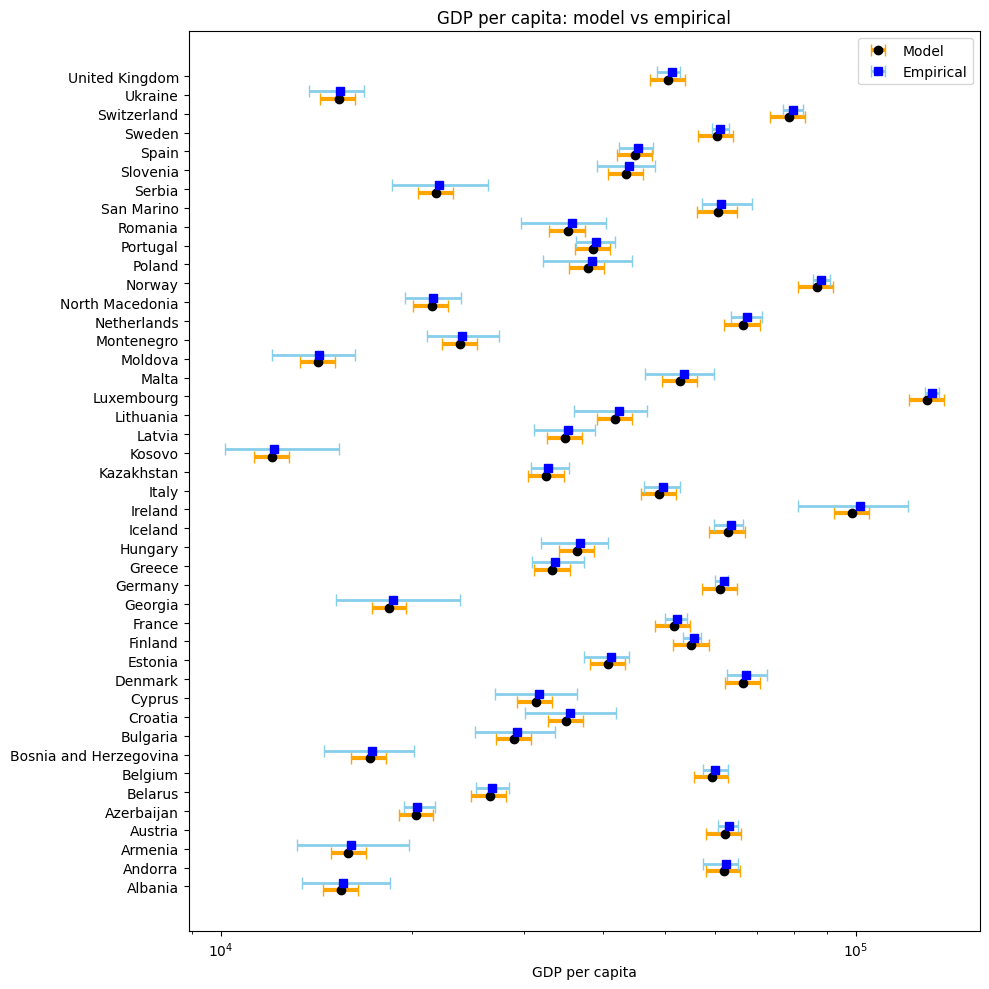

In [35]:
plot_gdp_percap_dist(df_plot[df_plot.country.isin(countries2plot)], show_empirical=True, log_xscale=True)

### posterior predictive checks

In [41]:
with model1:
    ppc = pm.sample_posterior_predictive(trace_model1, var_names=["gdp_obs", "pop_obs"])

Sampling: [gdp_obs, pop_obs]


Output()

In [42]:
gdp_log_ppc = m_g + s_g * ppc.posterior_predictive["gdp_obs"].values
pop_log_ppc = m_p + s_p * ppc.posterior_predictive["pop_obs"].values

gdp_percap_ppc = np.exp(gdp_log_ppc - pop_log_ppc)   # shape: (draws, chains?, obs) or similar
# reshape to (n_draws_total, n_obs):
gdp_percap_ppc = gdp_percap_ppc.reshape(-1, df_model.shape[0])

hdis  = az.hdi(gdp_percap_ppc, hdi_prob=0.89)         # (n_obs, 2)
means = gdp_percap_ppc.mean(axis=0)                   # (n_obs,)

/tmp/ipykernel_724/36310265.py:8: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis  = az.hdi(gdp_percap_ppc, hdi_prob=0.89)         # (n_obs, 2)


In [43]:
df_plot_ppc=get_hdi_df(df_model, hdis, means)

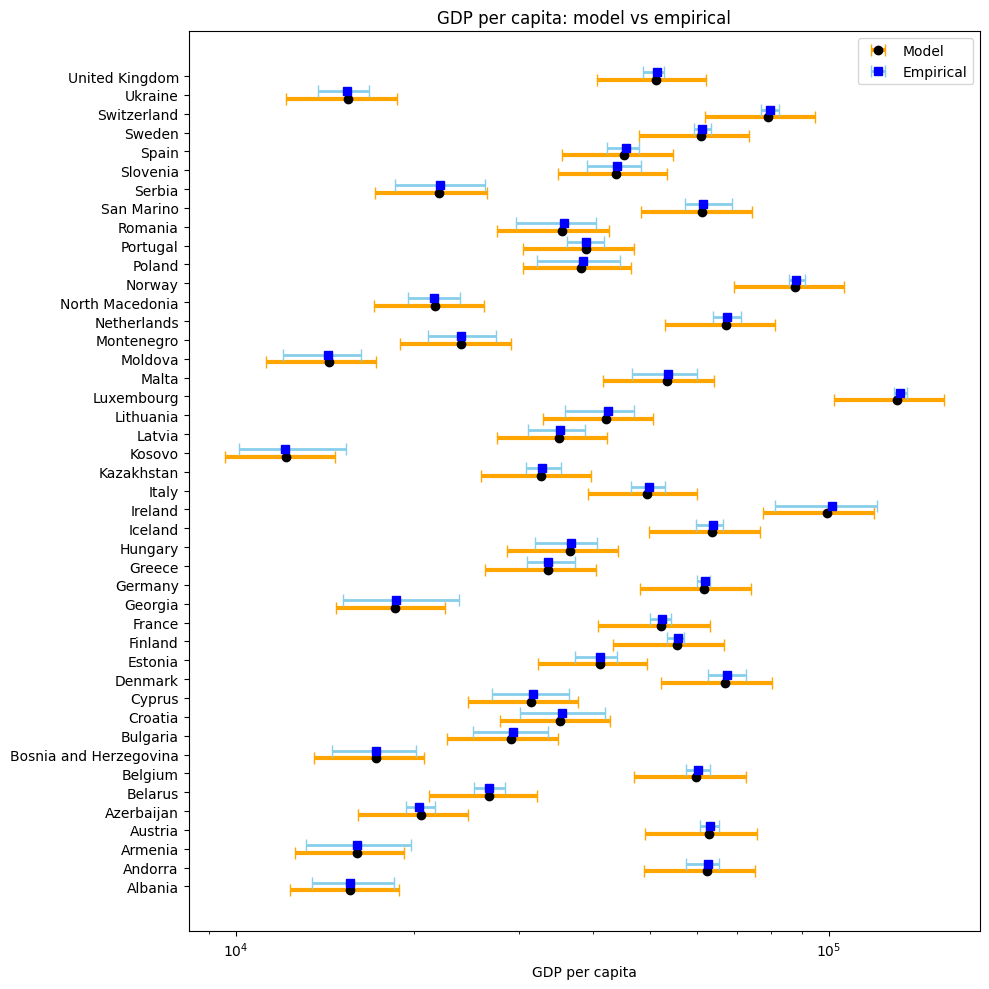

In [44]:
plot_gdp_percap_dist(df_plot_ppc[df_plot_ppc.country.isin(countries2plot)], show_empirical=True, log_xscale=True)

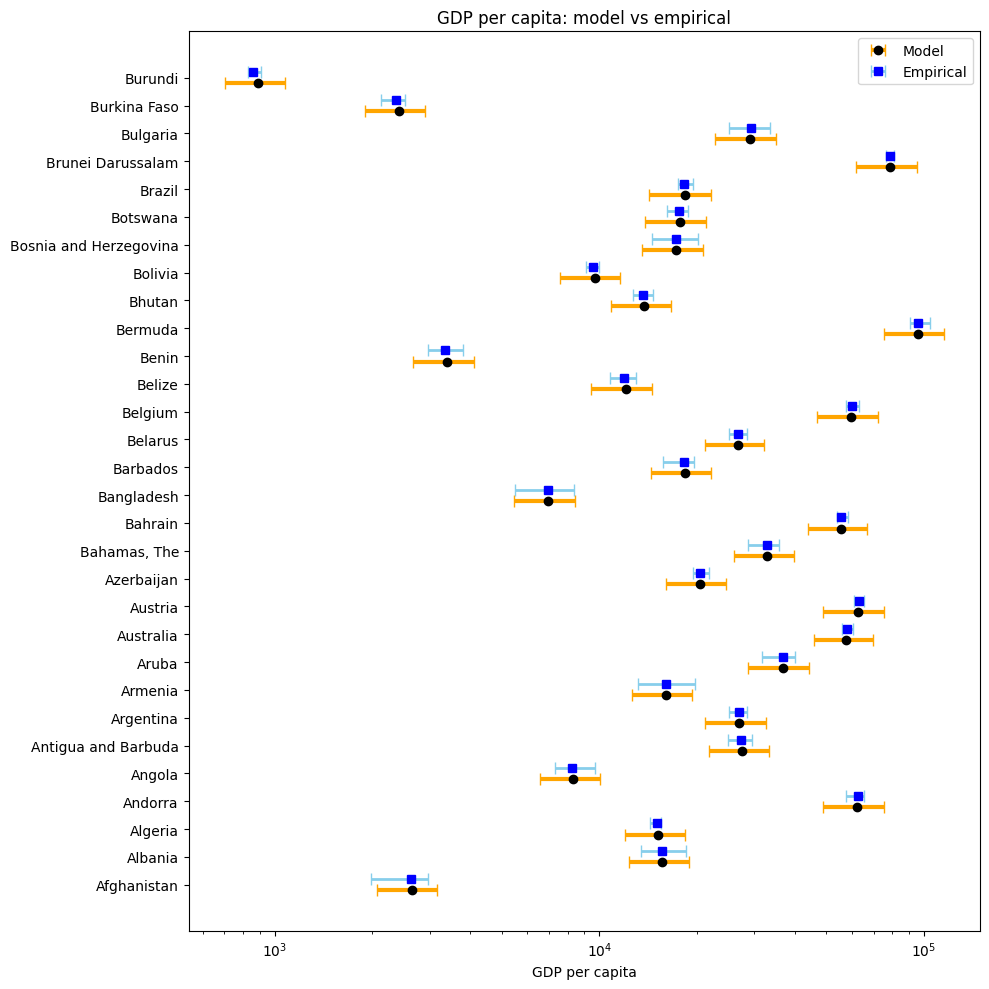

In [45]:
plot_gdp_percap_dist(df_plot_ppc.head(30), show_empirical=True, log_xscale=True)

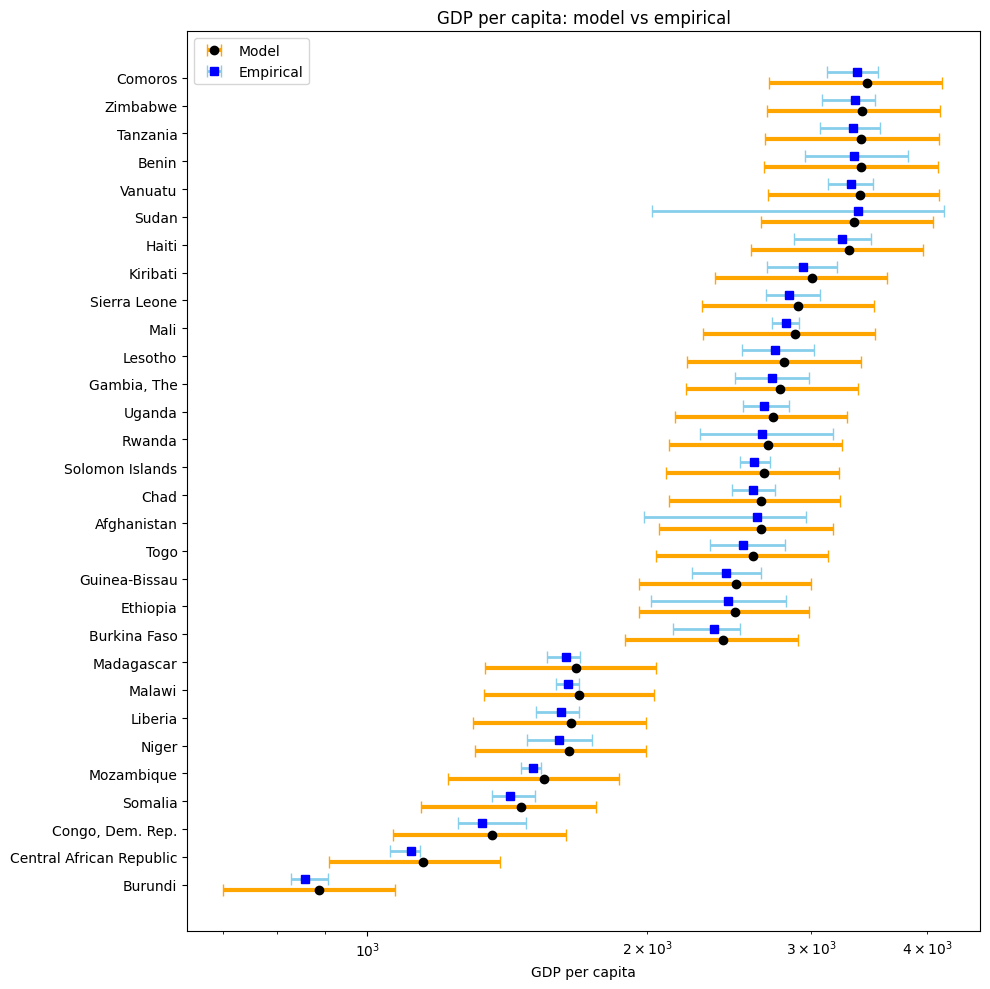

In [49]:
df_plot_ppc['hdi_interval']=df_plot_ppc['hdi_high_model']-df_plot_ppc['hdi_low_model']

plot_gdp_percap_dist(df_plot_ppc.sort_values('hdi_interval').head(30), show_empirical=True, log_xscale=True)

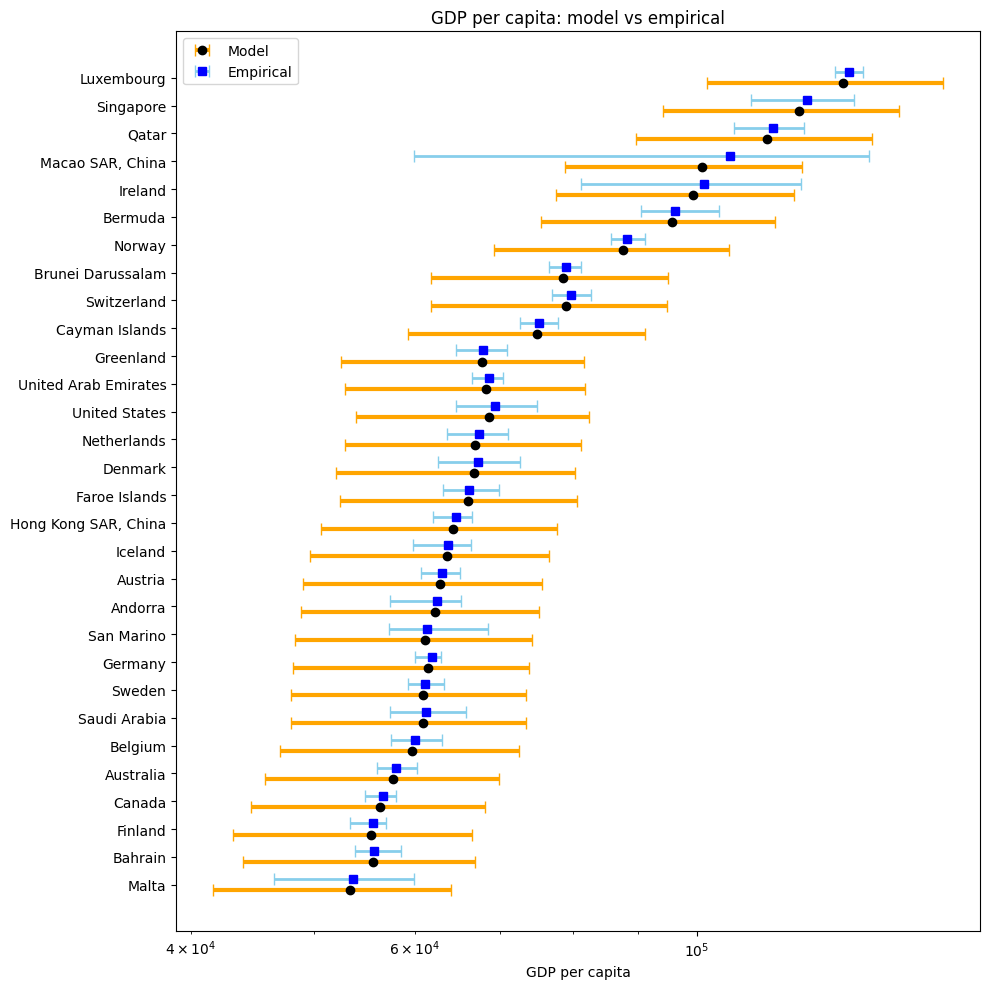

In [50]:
plot_gdp_percap_dist(df_plot_ppc.sort_values('hdi_interval').tail(30), show_empirical=True, log_xscale=True)

In [46]:
df_plot_ppc

,country,year,GDP,Population,gdp_log,population_log,gdp_log_std,population_log_std,country_idx,year_idx,hdi_high_model,hdi_low_model,hdi_mean_model,gdp_percap_emp,hdi_high_emp,hdi_low_emp,hdi_mean_emp
0,Afghanistan,2015,1.004023e+11,33831764,25.332451,17.336911,0.116372,0.813115,0,0,3162.841140,2058.788639,2649.281612,2967.692067,2963.773133,1982.635247,2620.943194
1,Albania,2015,3.789949e+10,2880703,24.358203,14.873545,-0.289444,-0.252299,1,0,18876.019899,12324.440763,15604.327360,13156.332209,18460.055169,13421.724797,15560.568974
2,Algeria,2015,6.098783e+11,40019529,27.136525,17.504878,0.867846,0.885761,2,0,18301.400033,11974.436378,15156.219700,15239.517146,15477.252969,14343.997060,15079.616253
3,Andorra,2015,4.482377e+09,72174,22.223419,11.186835,-1.178673,-1.846814,3,0,75102.290902,48820.552872,62267.649785,62105.154239,65286.286848,57391.128042,62530.579990
4,Angola,2015,2.810410e+11,28157798,26.361766,17.153335,0.545126,0.733718,4,0,10025.554030,6554.868112,8274.541263,9980.929882,9684.365405,7296.805326,8225.674299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Viet Nam,2015,8.584317e+11,92823254,27.478373,18.346208,1.010241,1.249639,194,0,14013.172572,9084.905317,11679.425192,9248.023961,13984.921714,9493.130271,11668.848168
195,Virgin Islands (U.S.),2015,4.603512e+09,107712,22.250085,11.587216,-1.167565,-1.673647,195,0,54198.863856,35329.583128,44719.519811,42739.083502,46734.063437,42946.240895,44723.168469
196,West Bank and Gaza,2015,2.593078e+10,4270092,23.978696,15.267146,-0.447525,-0.082065,196,0,7039.386340,4600.796694,5803.310483,6072.650318,6445.651062,4595.738837,5762.292995
197,Zambia,2015,5.865832e+10,16399089,24.794995,16.612736,-0.107501,0.499907,197,0,4445.917707,2889.798692,3662.299029,3576.925448,3694.973541,3446.757965,3589.540261


In [90]:
#on standardized scale
# Extract draws
a_gdp_c = trace_model1.posterior["a_gdp_c"].values.reshape(-1, N_COUNTRIES)
a_pop_c = trace_model1.posterior["a_pop_c"].values.reshape(-1, N_COUNTRIES)
beta_pop = trace_model1.posterior["beta_pop"].values.reshape(-1, 1)  # broadcast over countries

# Country-level expected standardized log-GDP: a_gdp_c + beta_pop * a_pop_c
mu_gdp_std = a_gdp_c + beta_pop * a_pop_c  # shape: (draws, countries)

# Model summaries on std-log scale
hdi_model = az.hdi(mu_gdp_std, hdi_prob=0.89)          # (countries, 2)
mean_model = mu_gdp_std.mean(axis=0)                   # (countries,)

# Empirical standardized log-GDP per observation
# log_gdp_emp = np.log(df_model["GDP"].values)
log_gdp_std_emp = df_model['gdp_log_std']
emp_df = pd.DataFrame({"country": df_model["country"].values, "log_gdp_std_emp": log_gdp_std_emp})

# Aggregate empirical to country level (mean and 89% equal-tail, or use HDI if you prefer)
emp_country = (
    emp_df.groupby("country")["log_gdp_std_emp"]
          .agg(mean_emp="mean",
               low89=lambda x: np.percentile(x, 5.5),
               high89=lambda x: np.percentile(x, 94.5))
)

# Package model country table
model_country = pd.DataFrame({
    "country": [idx_to_country[i] for i in range(N_COUNTRIES)],
    "mean_model": mean_model,
    "low_model": hdi_model[:,0],
    "high_model": hdi_model[:,1],
})#.set_index("country")

# Join for comparison on the SAME (std-log) scale
df_gdp_stdlog = model_country.merge(emp_country,on='country', how="left")

/tmp/ipykernel_724/1975945040.py:11: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_model = az.hdi(mu_gdp_std, hdi_prob=0.89)          # (countries, 2)


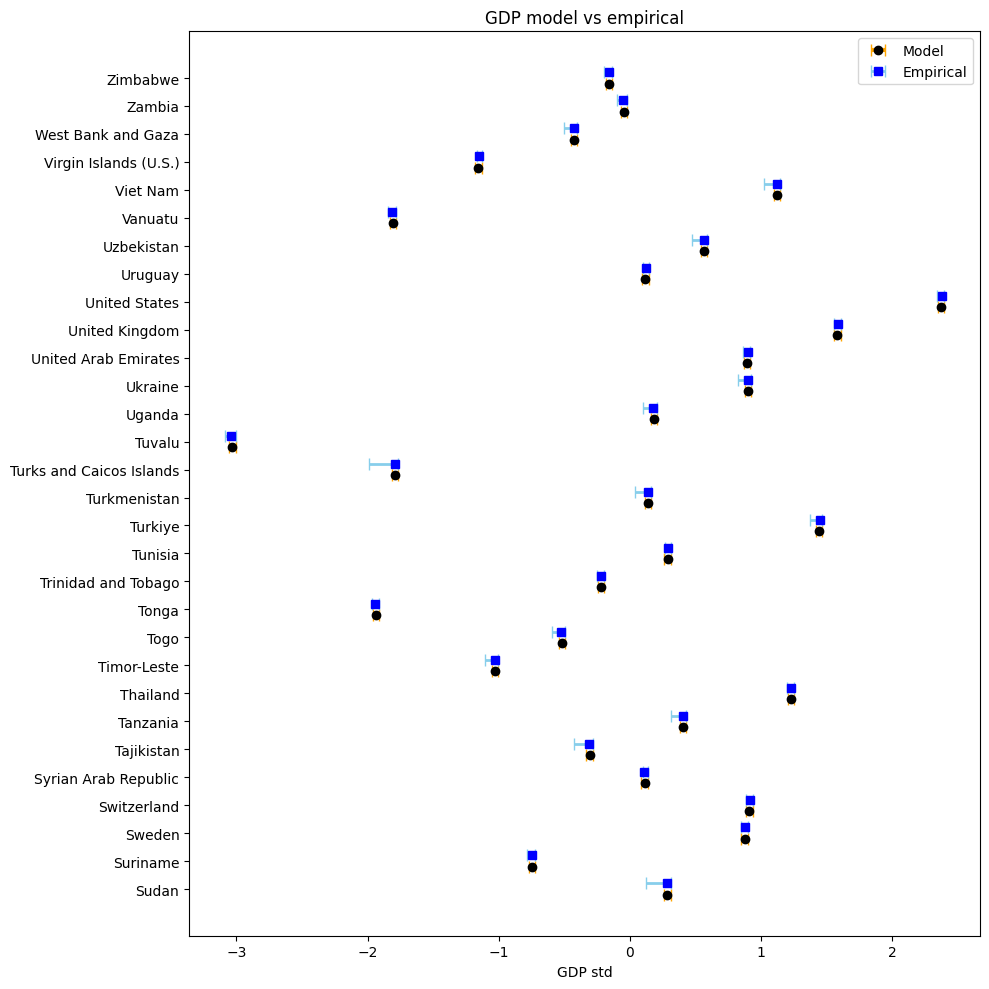

In [104]:
plot_gdp_percap_dist(df_gdp_stdlog.tail(30), show_empirical=True, log_xscale=False,
                    hdi_mean_col='mean_model',
                     hdi_low_col='low_model',
                     hdi_high_col='high_model',
                     hdi_mean_emp_col='mean_emp',
                     hdi_low_emp_col='low89',
                     hdi_high_emp_col='high89',
                    title='GDP model vs empirical',
                    xlabel='GDP std')

In [108]:
#keep gdp on original scale
# Back-transform model: log-GDP (original units)
log_gdp_country = m_g + s_g * mu_gdp_std              # (draws, countries)

# GDP in original units
gdp_country = np.exp(log_gdp_country)                 # (draws, countries)

# Summaries in original units
hdi_model_gdp = az.hdi(gdp_country, hdi_prob=0.89)    # (countries, 2)
mean_model_gdp = gdp_country.mean(axis=0)             # (countries,)

# Empirical GDP per country (aggregate your raw GDP by country across years)
emp_gdp_country = (
    df_model.groupby("country")["GDP"]
            .agg(mean_emp="mean",
                 low89=lambda x: np.percentile(x, 5.5),
                 high89=lambda x: np.percentile(x, 94.5))
)

model_gdp_country = pd.DataFrame({
    "country": [idx_to_country[i] for i in range(N_COUNTRIES)],
    "mean_model_gdp": mean_model_gdp,
    "low_model_gdp": hdi_model_gdp[:,0],
    "high_model_gdp": hdi_model_gdp[:,1],
})#.set_index("country")

df_gdp_orig = model_gdp_country.merge(emp_gdp_country, on='country', how="left")

/tmp/ipykernel_724/1204289403.py:9: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_model_gdp = az.hdi(gdp_country, hdi_prob=0.89)    # (countries, 2)


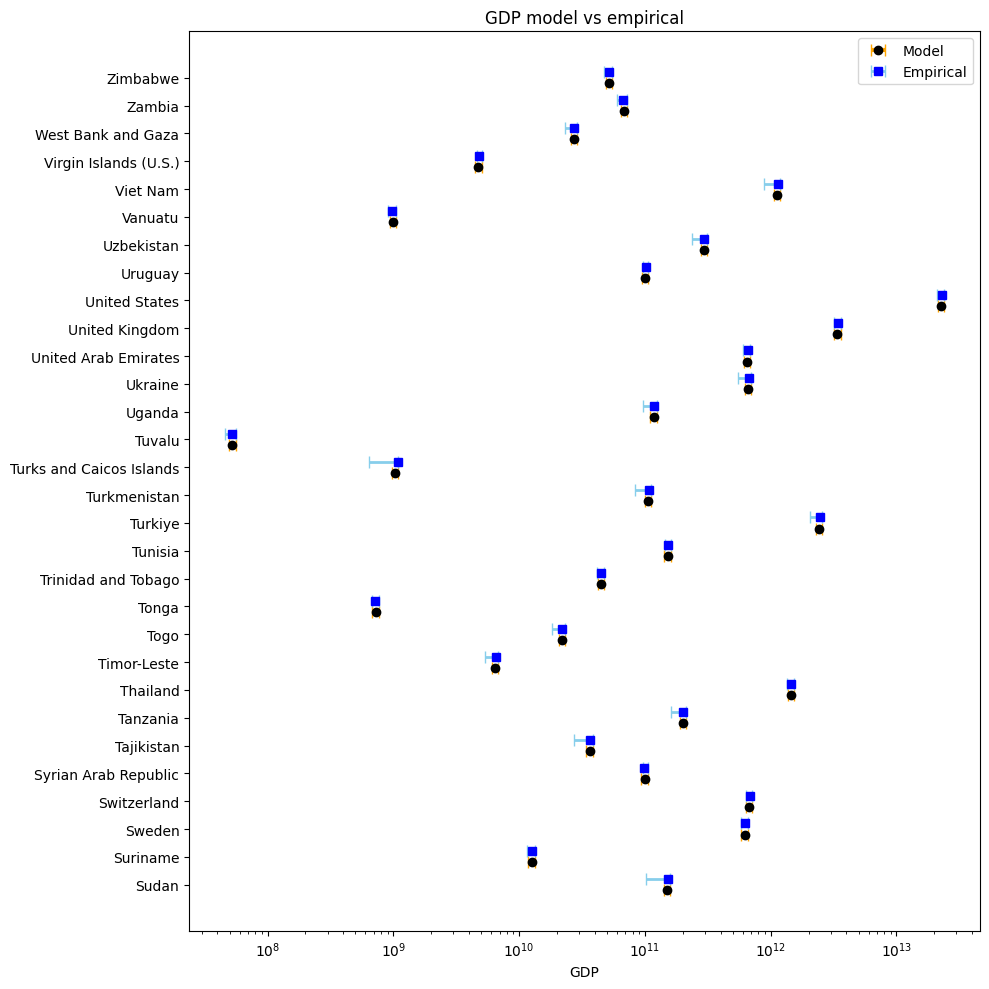

In [110]:
plot_gdp_percap_dist(df_gdp_orig.tail(30), show_empirical=True, log_xscale=True,
                    hdi_mean_col='mean_model_gdp',
                     hdi_low_col='low_model_gdp',
                     hdi_high_col='high_model_gdp',
                     hdi_mean_emp_col='mean_emp',
                     hdi_low_emp_col='low89',
                     hdi_high_emp_col='high89',
                    title='GDP model vs empirical',
                    xlabel='GDP')

In [106]:
df_gdp_orig

,mean_model_gdp,low_model_gdp,high_model_gdp,mean_emp,low89,high89
country,,,,,,
Afghanistan,9.875035e+10,9.269805e+10,1.046591e+11,9.806116e+10,8.121761e+10,1.096678e+11
Albania,4.366759e+10,4.108196e+10,4.613932e+10,4.384069e+10,3.863281e+10,5.039121e+10
Algeria,6.553288e+11,6.175066e+11,6.944585e+11,6.565948e+11,6.174330e+11,7.114808e+11
Andorra,4.758121e+09,4.487352e+09,5.037150e+09,4.803430e+09,4.387095e+09,5.314812e+09
Angola,2.691762e+11,2.533276e+11,2.844908e+11,2.682810e+11,2.542897e+11,2.796541e+11
...,...,...,...,...,...,...
Viet Nam,1.125791e+12,1.058345e+12,1.190721e+12,1.139964e+12,8.868591e+11,1.408044e+12
Virgin Islands (U.S.),4.739378e+09,4.433364e+09,5.056165e+09,4.771784e+09,4.618644e+09,4.939557e+09
West Bank and Gaza,2.729113e+10,2.571354e+10,2.888491e+10,2.721278e+10,2.310716e+10,2.919814e+10


In [119]:
a_gdp_c = trace_model1.posterior["a_gdp_c"].values.reshape(-1, N_COUNTRIES).mean(axis=0)
a_pop_c = trace_model1.posterior["a_pop_c"].values.reshape(-1, N_COUNTRIES).mean(axis=0)

Text(0, 0.5, 'a_pop_c')

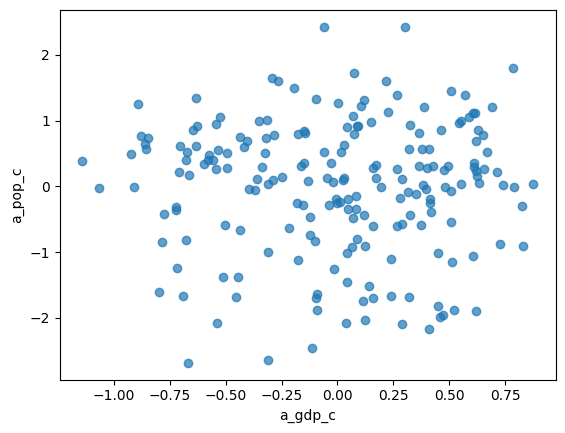

In [123]:
plt.scatter(a_gdp_c, a_pop_c, alpha=0.7)
plt.xlabel("a_gdp_c")
plt.ylabel("a_pop_c")

High a_gdp_c & low a_pop_c

→ The model says: country has above-average GDP, but below-average population.

→ Because mu_gdp combines a_gdp_c + beta_pop * a_pop_c, the GDP is less dependent on population size in such cases — it’s being propped up more by the GDP-specific intercept.

→ Interpretation: richer than expected given population size.

Low a_gdp_c & high a_pop_c

→ Country has below-average GDP, but above-average population.

→ So population contributes positively, but the country’s GDP intercept is dragging it down.

→ Interpretation: poorer than expected given population size.

In [126]:
trace_model1.posterior['beta_pop'].shape

(4, 4000)

## Model 2

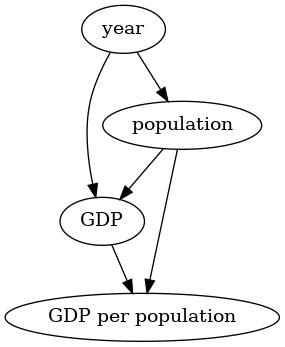

In [129]:
dot = Digraph()

dot.node('GDP')
dot.node('year')
dot.node('population')
dot.node('GDP per population')

dot.edges([('population', 'GDP'), 
           ('year', 'GDP'),
           ('year', 'population'),
           ('population', 'GDP per population'), 
           ('GDP', 'GDP per population')])

png = dot.pipe(format='png')
display(Image(png))

In [164]:
N_YEARS     = int(df_model['year_idx'].max()+1)

#simple fixed year effects
with pm.Model() as model2:
    # --- population (country intercepts) ---
    mu_pop_c    = pm.Normal("mu_pop_c", 0, 0.3)
    sigma_pop_c = pm.HalfNormal("sigma_pop_c", 0.2)
    a_pop_c     = pm.Normal("a_pop_c", mu_pop_c, sigma_pop_c, shape=N_COUNTRIES)

    # year effects for population (sum-to-zero centered)
    sigma_year_pop = pm.HalfNormal("sigma_year_pop", 0.1)
    a_year_pop_raw = pm.Normal("a_year_pop_raw", 0, 1, shape=N_YEARS)
    a_year_pop     = pm.Deterministic(
        "a_year_pop", sigma_year_pop * (a_year_pop_raw - pt.mean(a_year_pop_raw))
    )

    sigma_me_p  = pm.HalfNormal("sigma_me_p", 0.1)
    mu_pop = a_pop_c[df_model.country_idx] + a_year_pop[df_model.year_idx]
    pm.Normal("pop_obs", mu=mu_pop, sigma=sigma_me_p,
              observed=df_model["population_log_std"].values)

    # --- GDP (country intercepts + population + year effects) ---
    mu_gdp_c    = pm.Normal("mu_gdp_c", 0, 0.1)
    sigma_gdp_c = pm.HalfNormal("sigma_gdp_c", 0.1)
    z_gdp_c     = pm.Normal("z_gdp_c", 0, 0.05, shape=N_COUNTRIES)
    a_gdp_c     = pm.Deterministic("a_gdp_c", mu_gdp_c + sigma_gdp_c * z_gdp_c)

    beta_pop  = pm.Normal("beta_pop", 1.0, 0.2)

    sigma_year_gdp = pm.HalfNormal("sigma_year_gdp", 0.3)
    a_year_gdp_raw = pm.Normal("a_year_gdp_raw", 0, 1, shape=N_YEARS)
    a_year_gdp     = pm.Deterministic(
        "a_year_gdp", sigma_year_gdp * (a_year_gdp_raw - pt.mean(a_year_gdp_raw))
    )

    sigma_gdp = pm.HalfNormal("sigma_gdp", 0.3)
    mu_gdp = (a_gdp_c[df_model.country_idx]
              + beta_pop * a_pop_c[df_model.country_idx]
              + a_year_gdp[df_model.year_idx])
    pm.Normal("gdp_obs", mu=mu_gdp, sigma=sigma_gdp,
              observed=df_model["gdp_log_std"].values)
    
    # Back-transform (mean log-levels)
    log_pop_true = pm.Deterministic("log_pop_true", m_p + s_p * a_pop_c[df_model.country_idx])
    log_gdp_true = pm.Deterministic("log_gdp_true", m_g + s_g * mu_gdp)
    log_gdp_percap = pm.Deterministic("log_gdp_percap", log_gdp_true - log_pop_true)
    gdp_percap = pm.Deterministic("gdp_percap", pm.math.exp(log_gdp_percap))

In [165]:
N_YEARS

10

In [166]:
with model2:
    prior_pred2 = pm.sample_prior_predictive(1000) 

Sampling: [a_pop_c, a_year_gdp_raw, a_year_pop_raw, beta_pop, gdp_obs, mu_gdp_c, mu_pop_c, pop_obs, sigma_gdp, sigma_gdp_c, sigma_me_p, sigma_pop_c, sigma_year_gdp, sigma_year_pop, z_gdp_c]


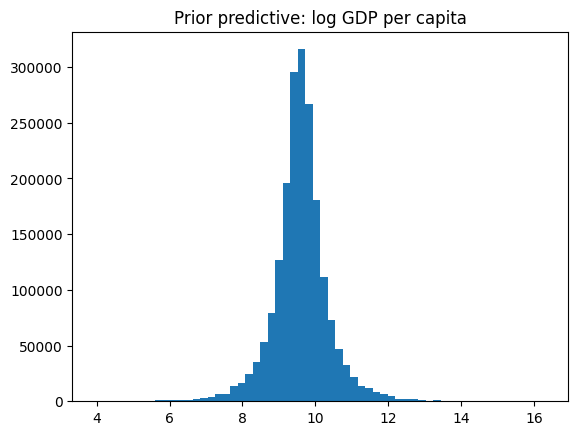

In [167]:
lgpc = prior_pred2.prior["log_gdp_percap"].values.ravel()
plt.hist(lgpc[np.isfinite(lgpc)], bins=60)
plt.title("Prior predictive: log GDP per capita")
plt.show()

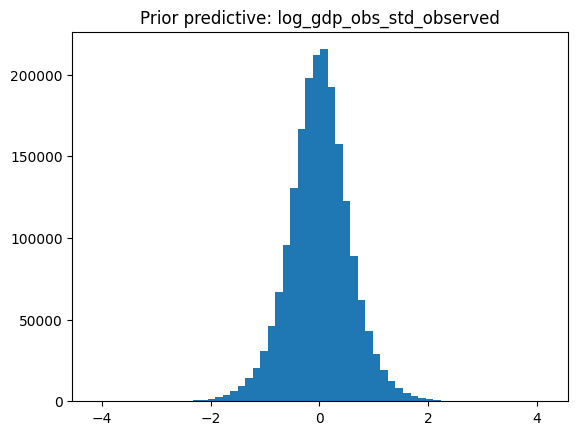

In [168]:
# Fake observed standardized logs (should look roughly N(0, ~1) if your priors are very wide)
plt.hist(prior_pred2.prior_predictive["gdp_obs"].values.ravel(), bins=60)
plt.title("Prior predictive: log_gdp_obs_std_observed")
plt.show()

## Sample

In [169]:
with model2:
    trace_model2 = pm.sample(draws=4000, tune=4000,
                             target_accept=0.995, random_seed=42,
                            init="jitter+adapt_diag")
    post_pred_model2 = pm.sample_posterior_predictive(trace_model2, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop_c, sigma_pop_c, a_pop_c, sigma_year_pop, a_year_pop_raw, sigma_me_p, mu_gdp_c, sigma_gdp_c, z_gdp_c, beta_pop, sigma_year_gdp, a_year_gdp_raw, sigma_gdp]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 304 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [gdp_obs, pop_obs]


Output()

In [170]:
df_summary2=az.summary(trace_model2)
df_summary2[df_summary2.r_hat>1.01].shape

(0, 9)

In [171]:
df_summary2.shape

(8538, 9)

In [172]:
df_summary2.sort_values('r_hat', ascending=False).head(30)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_gdp_c[35],-0.306,0.007,-0.318,-0.293,0.000,0.000,605.0,1795.0,1.01
z_gdp_c[140],0.021,0.006,0.010,0.032,0.000,0.000,406.0,1142.0,1.01
z_gdp_c[32],-0.116,0.006,-0.127,-0.105,0.000,0.000,435.0,1138.0,1.01
z_gdp_c[165],0.008,0.006,-0.003,0.018,0.000,0.000,440.0,1164.0,1.01
a_gdp_c[3],0.449,0.026,0.401,0.499,0.001,0.001,454.0,1315.0,1.01
z_gdp_c[36],-0.193,0.006,-0.205,-0.182,0.000,0.000,495.0,1241.0,1.01
z_gdp_c[163],0.019,0.006,0.007,0.031,0.000,0.000,388.0,954.0,1.01
z_gdp_c[38],0.087,0.010,0.068,0.106,0.001,0.000,343.0,716.0,1.01
z_gdp_c[39],0.042,0.006,0.031,0.054,0.000,0.000,401.0,933.0,1.01
z_gdp_c[162],-0.265,0.006,-0.277,-0.253,0.000,0.000,515.0,1404.0,1.01


array([[<Axes: title={'center': 'mu_pop_c'}>,
        <Axes: title={'center': 'mu_pop_c'}>],
       [<Axes: title={'center': 'sigma_pop_c'}>,
        <Axes: title={'center': 'sigma_pop_c'}>],
       [<Axes: title={'center': 'sigma_me_p'}>,
        <Axes: title={'center': 'sigma_me_p'}>],
       [<Axes: title={'center': 'mu_gdp_c'}>,
        <Axes: title={'center': 'mu_gdp_c'}>],
       [<Axes: title={'center': 'sigma_gdp_c'}>,
        <Axes: title={'center': 'sigma_gdp_c'}>],
       [<Axes: title={'center': 'beta_pop'}>,
        <Axes: title={'center': 'beta_pop'}>],
       [<Axes: title={'center': 'sigma_gdp'}>,
        <Axes: title={'center': 'sigma_gdp'}>],
       [<Axes: title={'center': 'sigma_year_pop'}>,
        <Axes: title={'center': 'sigma_year_pop'}>],
       [<Axes: title={'center': 'sigma_year_gdp'}>,
        <Axes: title={'center': 'sigma_year_gdp'}>]], dtype=object)

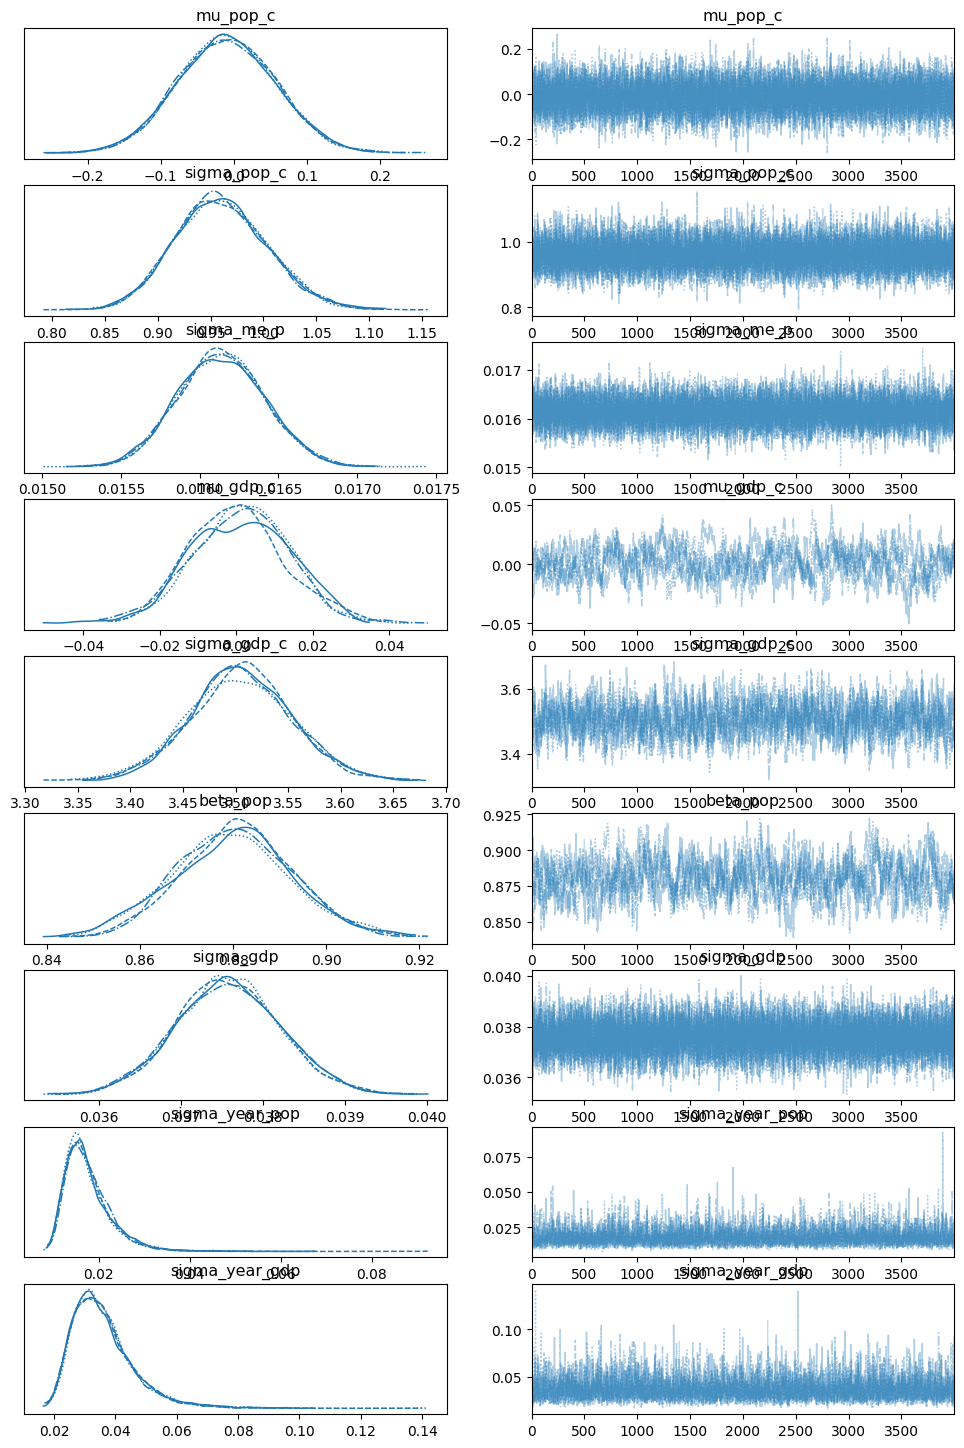

In [173]:
az.plot_trace(trace_model2, var_names=["mu_pop_c","sigma_pop_c", "sigma_me_p", "mu_gdp_c", "sigma_gdp_c", "beta_pop", "sigma_gdp", "sigma_year_pop", "sigma_year_gdp"])

## posterior predictive

In [174]:
gdp_log_ppc = m_g + s_g * post_pred_model2.posterior_predictive["gdp_obs"].values
pop_log_ppc = m_p + s_p * post_pred_model2.posterior_predictive["pop_obs"].values

gdp_percap_ppc = np.exp(gdp_log_ppc - pop_log_ppc)   # shape: (draws, chains?, obs) or similar
# reshape to (n_draws_total, n_obs):
gdp_percap_ppc = gdp_percap_ppc.reshape(-1, df_model.shape[0])

hdis  = az.hdi(gdp_percap_ppc, hdi_prob=0.89)         # (n_obs, 2)
means = gdp_percap_ppc.mean(axis=0)                   # (n_obs,)

/tmp/ipykernel_724/2679268595.py:8: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis  = az.hdi(gdp_percap_ppc, hdi_prob=0.89)         # (n_obs, 2)


In [175]:
df_plot_ppc2=get_hdi_df(df_model, hdis, means)

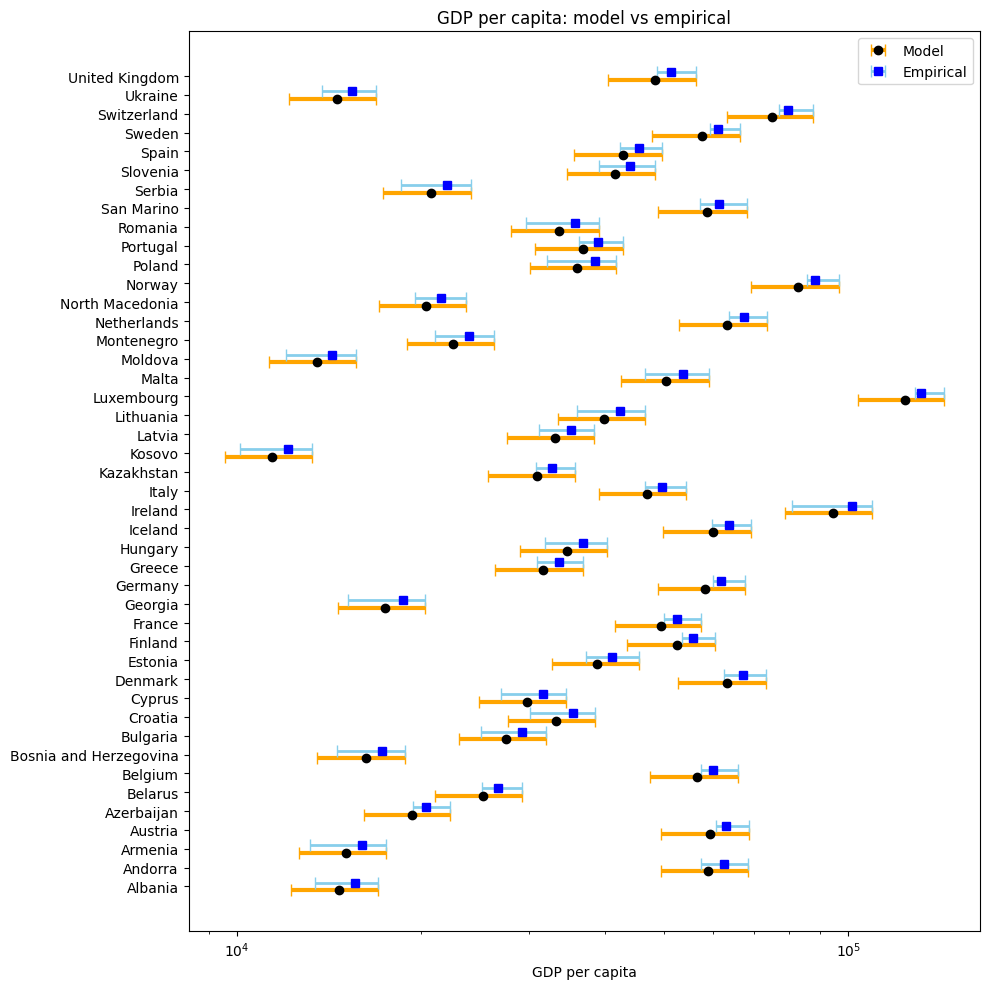

In [176]:
plot_gdp_percap_dist(df_plot_ppc2[df_plot_ppc2.country.isin(countries2plot)], show_empirical=True, log_xscale=True)

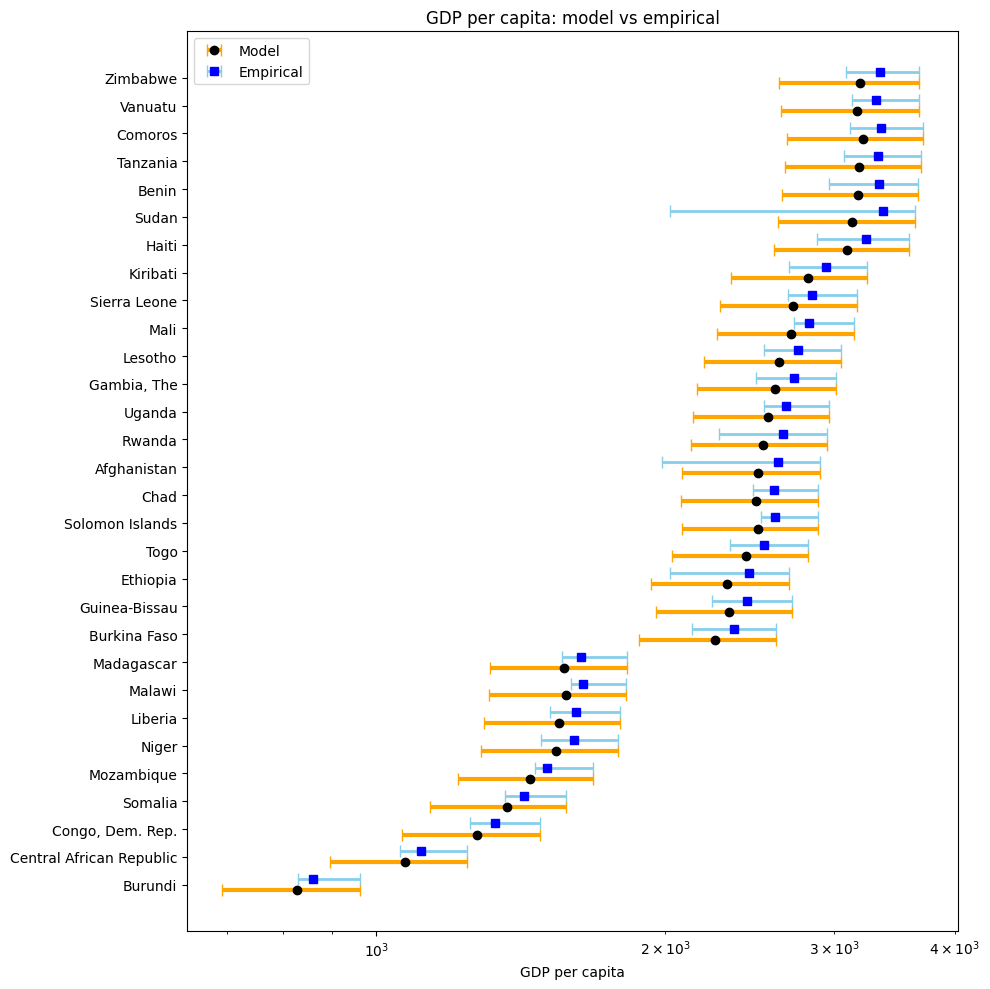

In [177]:
#now model seems to shring effects also on poorer countries
df_plot_ppc2['hdi_interval']=df_plot_ppc2['hdi_high_model']-df_plot_ppc2['hdi_low_model']

plot_gdp_percap_dist(df_plot_ppc2.sort_values('hdi_interval').head(30), show_empirical=True, log_xscale=True)

Text(0, 0.5, 'a_pop_c')

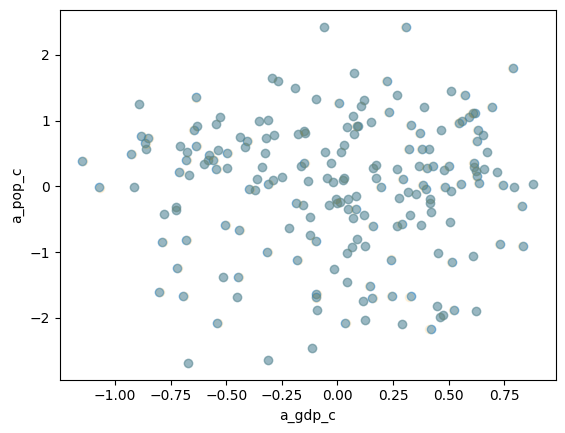

In [189]:
a_gdp_c2 = trace_model2.posterior["a_gdp_c"].values.reshape(-1, N_COUNTRIES).mean(axis=0)
a_pop_c2 = trace_model2.posterior["a_pop_c"].values.reshape(-1, N_COUNTRIES).mean(axis=0)

a_gdp_c = trace_model1.posterior["a_gdp_c"].values.reshape(-1, N_COUNTRIES).mean(axis=0)
a_pop_c = trace_model1.posterior["a_pop_c"].values.reshape(-1, N_COUNTRIES).mean(axis=0)

plt.scatter(a_gdp_c2, a_pop_c2, alpha=0.5)
plt.scatter(a_gdp_c, a_pop_c, alpha=0.1, color='orange')
plt.xlabel("a_gdp_c")
plt.ylabel("a_pop_c")

barely has changed

In [193]:
hdis_year=az.hdi(trace_model2.posterior['a_year_gdp'].values.reshape(-1, 10))
hdis_year=az.hdi(trace_model2.posterior['a_year_gdp'].values.reshape(-1, 10))

/tmp/ipykernel_724/834249748.py:1: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis_year=az.hdi(trace_model2.posterior['a_year_gdp'].values.reshape(-1, 10))


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

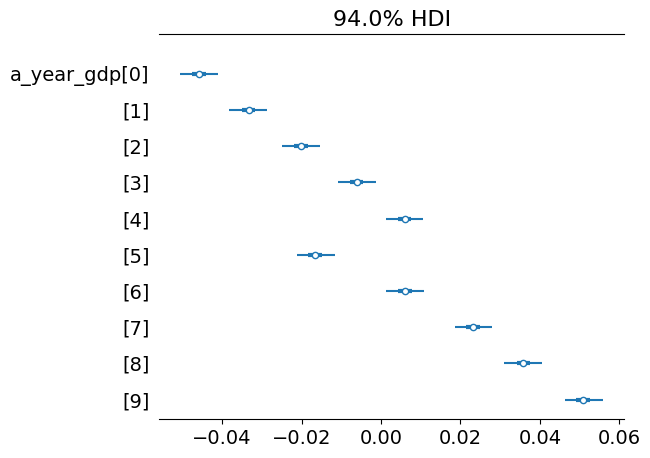

In [201]:
az.plot_forest(trace_model2.posterior, var_names=['a_year_gdp'], combined=True)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

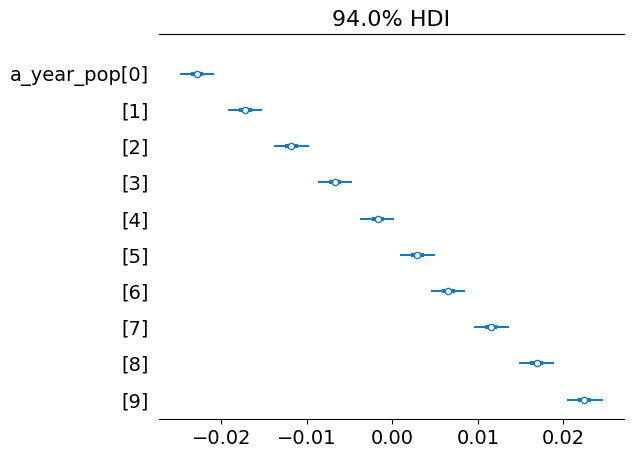

In [202]:
az.plot_forest(trace_model2.posterior, var_names=['a_year_pop'], combined=True)

In [203]:
#effect on scale
years = np.sort(df_model["year"].unique())

# Extract year effects from trace
a_year_gdp = trace_model2.posterior["a_year_gdp"].values.reshape(-1, len(years))
a_year_pop = trace_model2.posterior["a_year_pop"].values.reshape(-1, len(years))

# Back-transform to log scale of original units
log_gdp_effect = s_g * a_year_gdp       # Δlog(GDP)
log_pop_effect = s_p * a_year_pop       # Δlog(Pop)

# Multiplicative factor on original scale
gdp_factor = np.exp(log_gdp_effect)
pop_factor = np.exp(log_pop_effect)

# Summaries: mean + 89% HDI
def summarize_effect(effects, years, name):
    hdi = az.hdi(effects, hdi_prob=0.89)
    mean = effects.mean(axis=0)
    return pd.DataFrame({
        "year": years,
        f"{name}_mean": mean,
        f"{name}_low": hdi[:,0],
        f"{name}_high": hdi[:,1],
    })

df_gdp_year = summarize_effect(gdp_factor, years, "gdp_factor")
df_pop_year = summarize_effect(pop_factor, years, "pop_factor")

/tmp/ipykernel_724/1732363858.py:18: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(effects, hdi_prob=0.89)
/tmp/ipykernel_724/1732363858.py:18: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(effects, hdi_prob=0.89)


In [204]:
df_gdp_year

,year,gdp_factor_mean,gdp_factor_low,gdp_factor_high
0,2015,0.895953,0.887154,0.904485
1,2016,0.923120,0.914202,0.931883
2,2017,0.952847,0.943839,0.962249
3,2018,0.985430,0.975944,0.995006
4,2019,1.014425,1.005094,1.024556
5,2020,0.960969,0.951459,0.969970
6,2021,1.014605,1.004645,1.024221
7,2022,1.057303,1.046981,1.067335
8,2023,1.089820,1.079180,1.100065
9,2024,1.130074,1.119413,1.141603


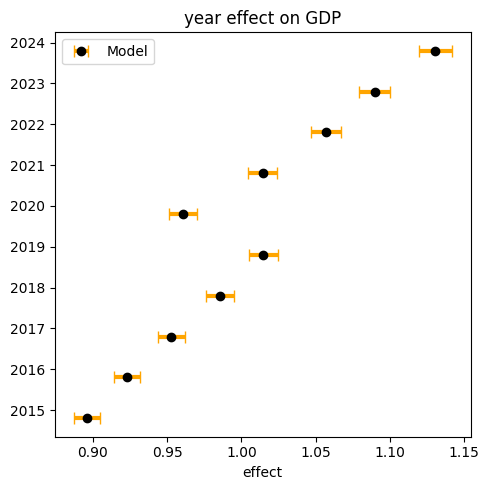

In [209]:
plot_gdp_percap_dist(df_gdp_year, show_empirical=False, log_xscale=False,
                   hdi_mean_col='gdp_factor_mean',
    hdi_low_col='gdp_factor_low',
    hdi_high_col='gdp_factor_high',
                    title='year effect on GDP',
                    xlabel='effect',
                    ylabel_col='year',
                    figsize=(5,5))

gdp_factor = 1.10 means GDP is about 10% higher than baseline that year.

pop_factor = 0.97 means population is about 3% lower than baseline that year.

In [210]:
df_pop_year

,year,pop_factor_mean,pop_factor_low,pop_factor_high
0,2015,0.948525,0.944921,0.952312
1,2016,0.961053,0.957189,0.964783
2,2017,0.973042,0.969208,0.976998
3,2018,0.984646,0.980910,0.988526
4,2019,0.996060,0.992067,0.999931
5,2020,1.006782,1.002732,1.010757
6,2021,1.015250,1.011225,1.019360
7,2022,1.026964,1.022801,1.031038
8,2023,1.039730,1.035407,1.043714
9,2024,1.053260,1.049010,1.057706


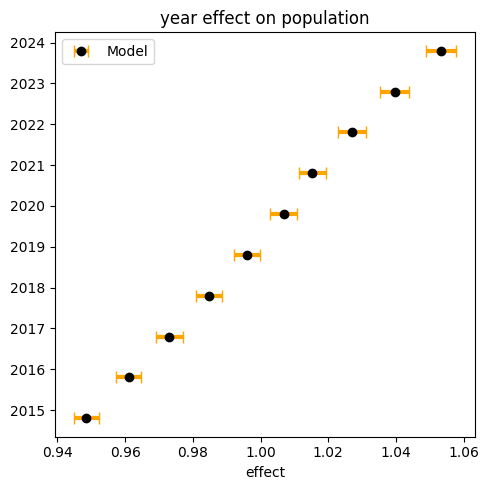

In [213]:
plot_gdp_percap_dist(df_pop_year, show_empirical=False, log_xscale=False,
                   hdi_mean_col='pop_factor_mean',
    hdi_low_col='pop_factor_low',
    hdi_high_col='pop_factor_high',
                    title='year effect on population',
                    xlabel='effect',
                    ylabel_col='year',
                    figsize=(5,5))

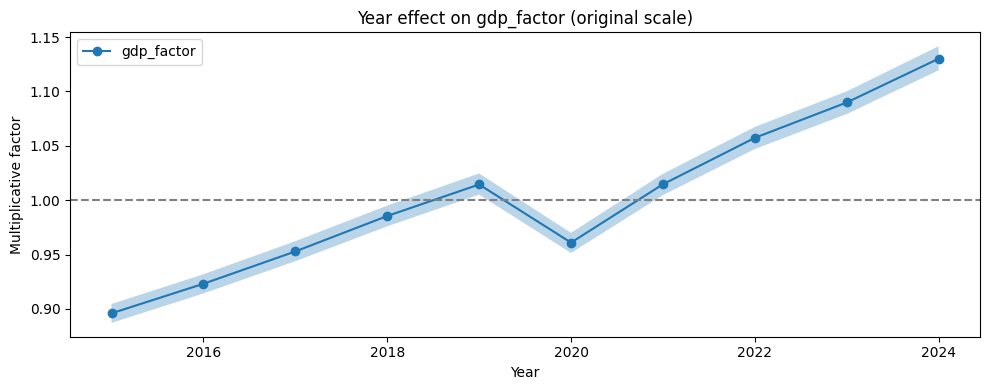

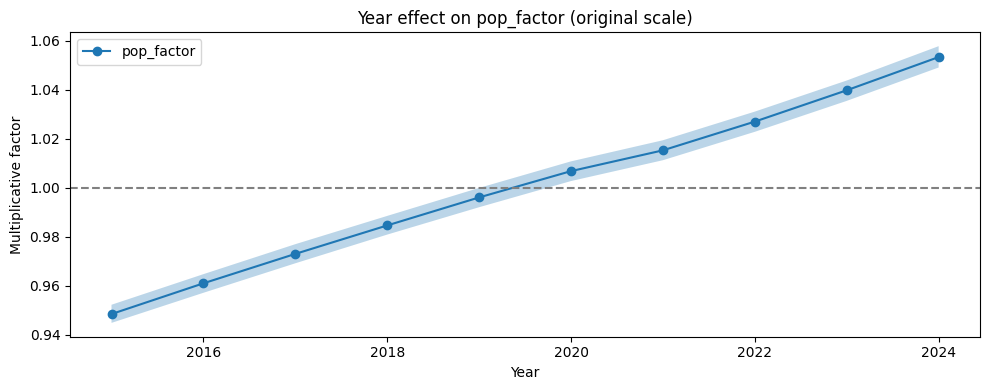

In [215]:
def plot_factors(df, name):
    plt.figure(figsize=(10,4))
    plt.fill_between(df["year"], df[f"{name}_low"], df[f"{name}_high"], alpha=0.3)
    plt.plot(df["year"], df[f"{name}_mean"], marker="o", label=name)
    plt.axhline(1.0, color="grey", ls="--")
    plt.ylabel("Multiplicative factor")
    plt.title(f"Year effect on {name} (original scale)")
    plt.xlabel("Year")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_factors(df_gdp_year, "gdp_factor")
plot_factors(df_pop_year, "pop_factor")